# HIGGS Machine Learning Pipeline
## Feature Selection & Hyperparameter Optimization

**Makine Öğrenmesi Final Ödevi**

`src/` altındaki modülleri kullanarak tum makine öğrenmesi hattini calistirir:

1. **Bolum 1 - Veri On Isleme:** IQR aykiri deger analizi + `MinMaxScaler`
2. **Bolum 2 - Ozellik Secimi:** ANOVA F-score / Mutual Information ile en iyi 15 ozellik
3. **Bolum 3 - Modelleme:** Nested Cross-Validation (Flowchart A & B), KNN / SVM / MLP / XGBoost

> Ayarlar `config.py` dosyasından yönetilir.Çıktı grafikleri `outputs/figures/`, tablolar `outputs/results/` altına kaydedilir.

## 0. Kurulum ve Ayarlar

In [1]:
import sys, os
sys.path.append(os.path.abspath('.'))

%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import Image, display

import config

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print('Veri yolu        :', config.DATA_PATH)
print('Ornek boyutu     :', config.SAMPLE_SIZE)
print('Modelleme ornegi :', config.MODEL_SAMPLE_SIZE)
print('Ozellik secimi   :', config.FEATURE_SELECTION_METHOD, '| en iyi', config.N_FEATURES_TO_SELECT)
print('Nested CV        : outer={}, inner={}'.format(config.OUTER_FOLDS, config.INNER_FOLDS))

Veri yolu        : C:\Users\Mehmet\Desktop\Yüksek Lisans\Makine Öğrenmesi\Final\MehmetŞen_254312024_MakineÖğrenmesi_Final\higgs\HIGGS.csv.gz
Ornek boyutu     : 100000
Modelleme ornegi : 6000
Ozellik secimi   : anova | en iyi 15
Nested CV        : outer=5, inner=3


## 1. Veri Yükleme(Rastgele 100.000 örnek)

Büyük gzip dosyası parça parça okunur ve rastgele 100.000 örnek toplanır. **İlk çalıştırmada bu kısım bir kaç dakika sürebilir.**; sonuç `outputs/` altında parquet olarak önbelleğe alınır, sonraki çalıştırmalar saniyeler içinde tamamlanır.

In [2]:
from src.data_loader import load_higgs_sample

X, y = load_higgs_sample()
print('X boyutu:', X.shape)
print('Sinif dagilimi:', dict(y.value_counts()))
X.head()

[data_loader] C:\Users\Mehmet\Desktop\Yüksek Lisans\Makine Öğrenmesi\Final\MehmetŞen_254312024_MakineÖğrenmesi_Final\higgs\HIGGS.csv.gz parca parca okunuyor ve rastgele 100000 ornek toplaniyor...
  - chunk 1: toplam toplanan ornek = 6818
  - chunk 2: toplam toplanan ornek = 13636
  - chunk 3: toplam toplanan ornek = 20454
  - chunk 4: toplam toplanan ornek = 27272
  - chunk 5: toplam toplanan ornek = 34090
  - chunk 6: toplam toplanan ornek = 40908
  - chunk 7: toplam toplanan ornek = 47726
  - chunk 8: toplam toplanan ornek = 54544
  - chunk 9: toplam toplanan ornek = 61362
  - chunk 10: toplam toplanan ornek = 68180
  - chunk 11: toplam toplanan ornek = 74998
  - chunk 12: toplam toplanan ornek = 81816
  - chunk 13: toplam toplanan ornek = 88634
  - chunk 14: toplam toplanan ornek = 95452
  - chunk 15: toplam toplanan ornek = 102270
[data_loader] Ornek onbellege kaydedildi: C:\Users\Mehmet\Desktop\Yüksek Lisans\Makine Öğrenmesi\Final\MehmetŞen_254312024_MakineÖğrenmesi_Final\outputs\

,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_b_tag,jet2_pt,jet2_eta,jet2_phi,jet2_b_tag,jet3_pt,jet3_eta,jet3_phi,jet3_b_tag,jet4_pt,jet4_eta,jet4_phi,jet4_b_tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,0.432817,1.465769,-0.060167,1.062385,1.263555,0.869902,0.273278,0.612746,0.000000,1.534386,1.129768,-0.248767,0.000000,1.804860,1.015100,-1.187333,2.548224,1.075373,0.760740,1.112992,1.550981,1.434813,1.087556,0.987253,1.066801,0.939439,1.137737,1.194219
1,2.615932,-0.366266,-0.658864,1.512848,-1.012174,1.620806,1.164485,0.655433,0.000000,1.198349,0.858755,1.319285,2.214872,0.512112,-1.470789,-1.381491,2.548224,0.622635,1.435327,-0.292148,0.000000,1.232831,1.191953,0.971429,0.864201,1.439139,1.310259,1.537660
2,2.934185,1.008978,-0.819219,0.550522,-1.261521,1.155991,-0.590203,1.103922,1.086538,1.399417,-1.068451,0.608548,1.107436,1.271323,-0.086301,-0.911075,0.000000,0.556672,-1.943437,1.207327,0.000000,1.542321,1.419926,0.984260,2.092507,0.939637,1.846966,1.564118
3,0.508399,0.058384,1.226105,2.489607,1.525123,0.899583,-0.209954,0.098285,2.173076,0.471131,-0.448714,-1.365087,2.214872,1.021414,-0.812679,0.773207,0.000000,1.827744,1.240446,-0.623988,0.000000,1.271247,1.046490,0.984073,1.601017,0.935433,1.101860,1.100971
4,0.320815,1.226173,-1.440664,2.264399,-1.613123,1.379055,-0.606046,-0.356405,2.173076,0.464710,1.559115,0.870427,0.000000,1.009647,-0.607873,0.810929,2.548224,1.422958,0.231897,-0.155639,0.000000,1.134159,1.079119,0.981032,4.047694,1.277336,2.814322,2.079151


## Bölüm 1 - Veri Ön İşleme
### 1.1 IQR ile Aykırı Değer Analizi

In [3]:
from src import preprocessing as prep

outlier_report = prep.analyze_outliers_iqr(X)
outlier_report

[preprocessing] Aykiri deger raporu kaydedildi: C:\Users\Mehmet\Desktop\Yüksek Lisans\Makine Öğrenmesi\Final\MehmetŞen_254312024_MakineÖğrenmesi_Final\outputs\results\outlier_report_iqr.csv


,feature,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_pct
23,m_lv,0.985764,1.018720,0.032956,0.936329,1.068154,20188,20.188
21,m_jj,0.790232,1.025924,0.235692,0.436693,1.379463,13780,13.780
22,m_jjj,0.846882,1.085718,0.238836,0.488628,1.443971,7536,7.536
26,m_wbb,0.820605,1.142363,0.321757,0.337970,1.624999,6351,6.351
25,m_bb,0.674630,1.138709,0.464079,-0.021488,1.834828,6130,6.130
27,m_wwbb,0.771092,1.063310,0.292218,0.332764,1.501637,5867,5.867
24,m_jlv,0.769289,1.142835,0.373546,0.208971,1.703154,5075,5.075
5,jet1_pt,0.680550,1.176809,0.496259,-0.063839,1.921198,4877,4.877
9,jet2_pt,0.657972,1.202756,0.544784,-0.159205,2.019933,3996,3.996
0,lepton_pT,0.591302,1.236409,0.645107,-0.376358,2.204070,3882,3.882


[preprocessing] Box-plot kaydedildi: C:\Users\Mehmet\Desktop\Yüksek Lisans\Makine Öğrenmesi\Final\MehmetŞen_254312024_MakineÖğrenmesi_Final\outputs\figures\boxplots_before_scaling.png


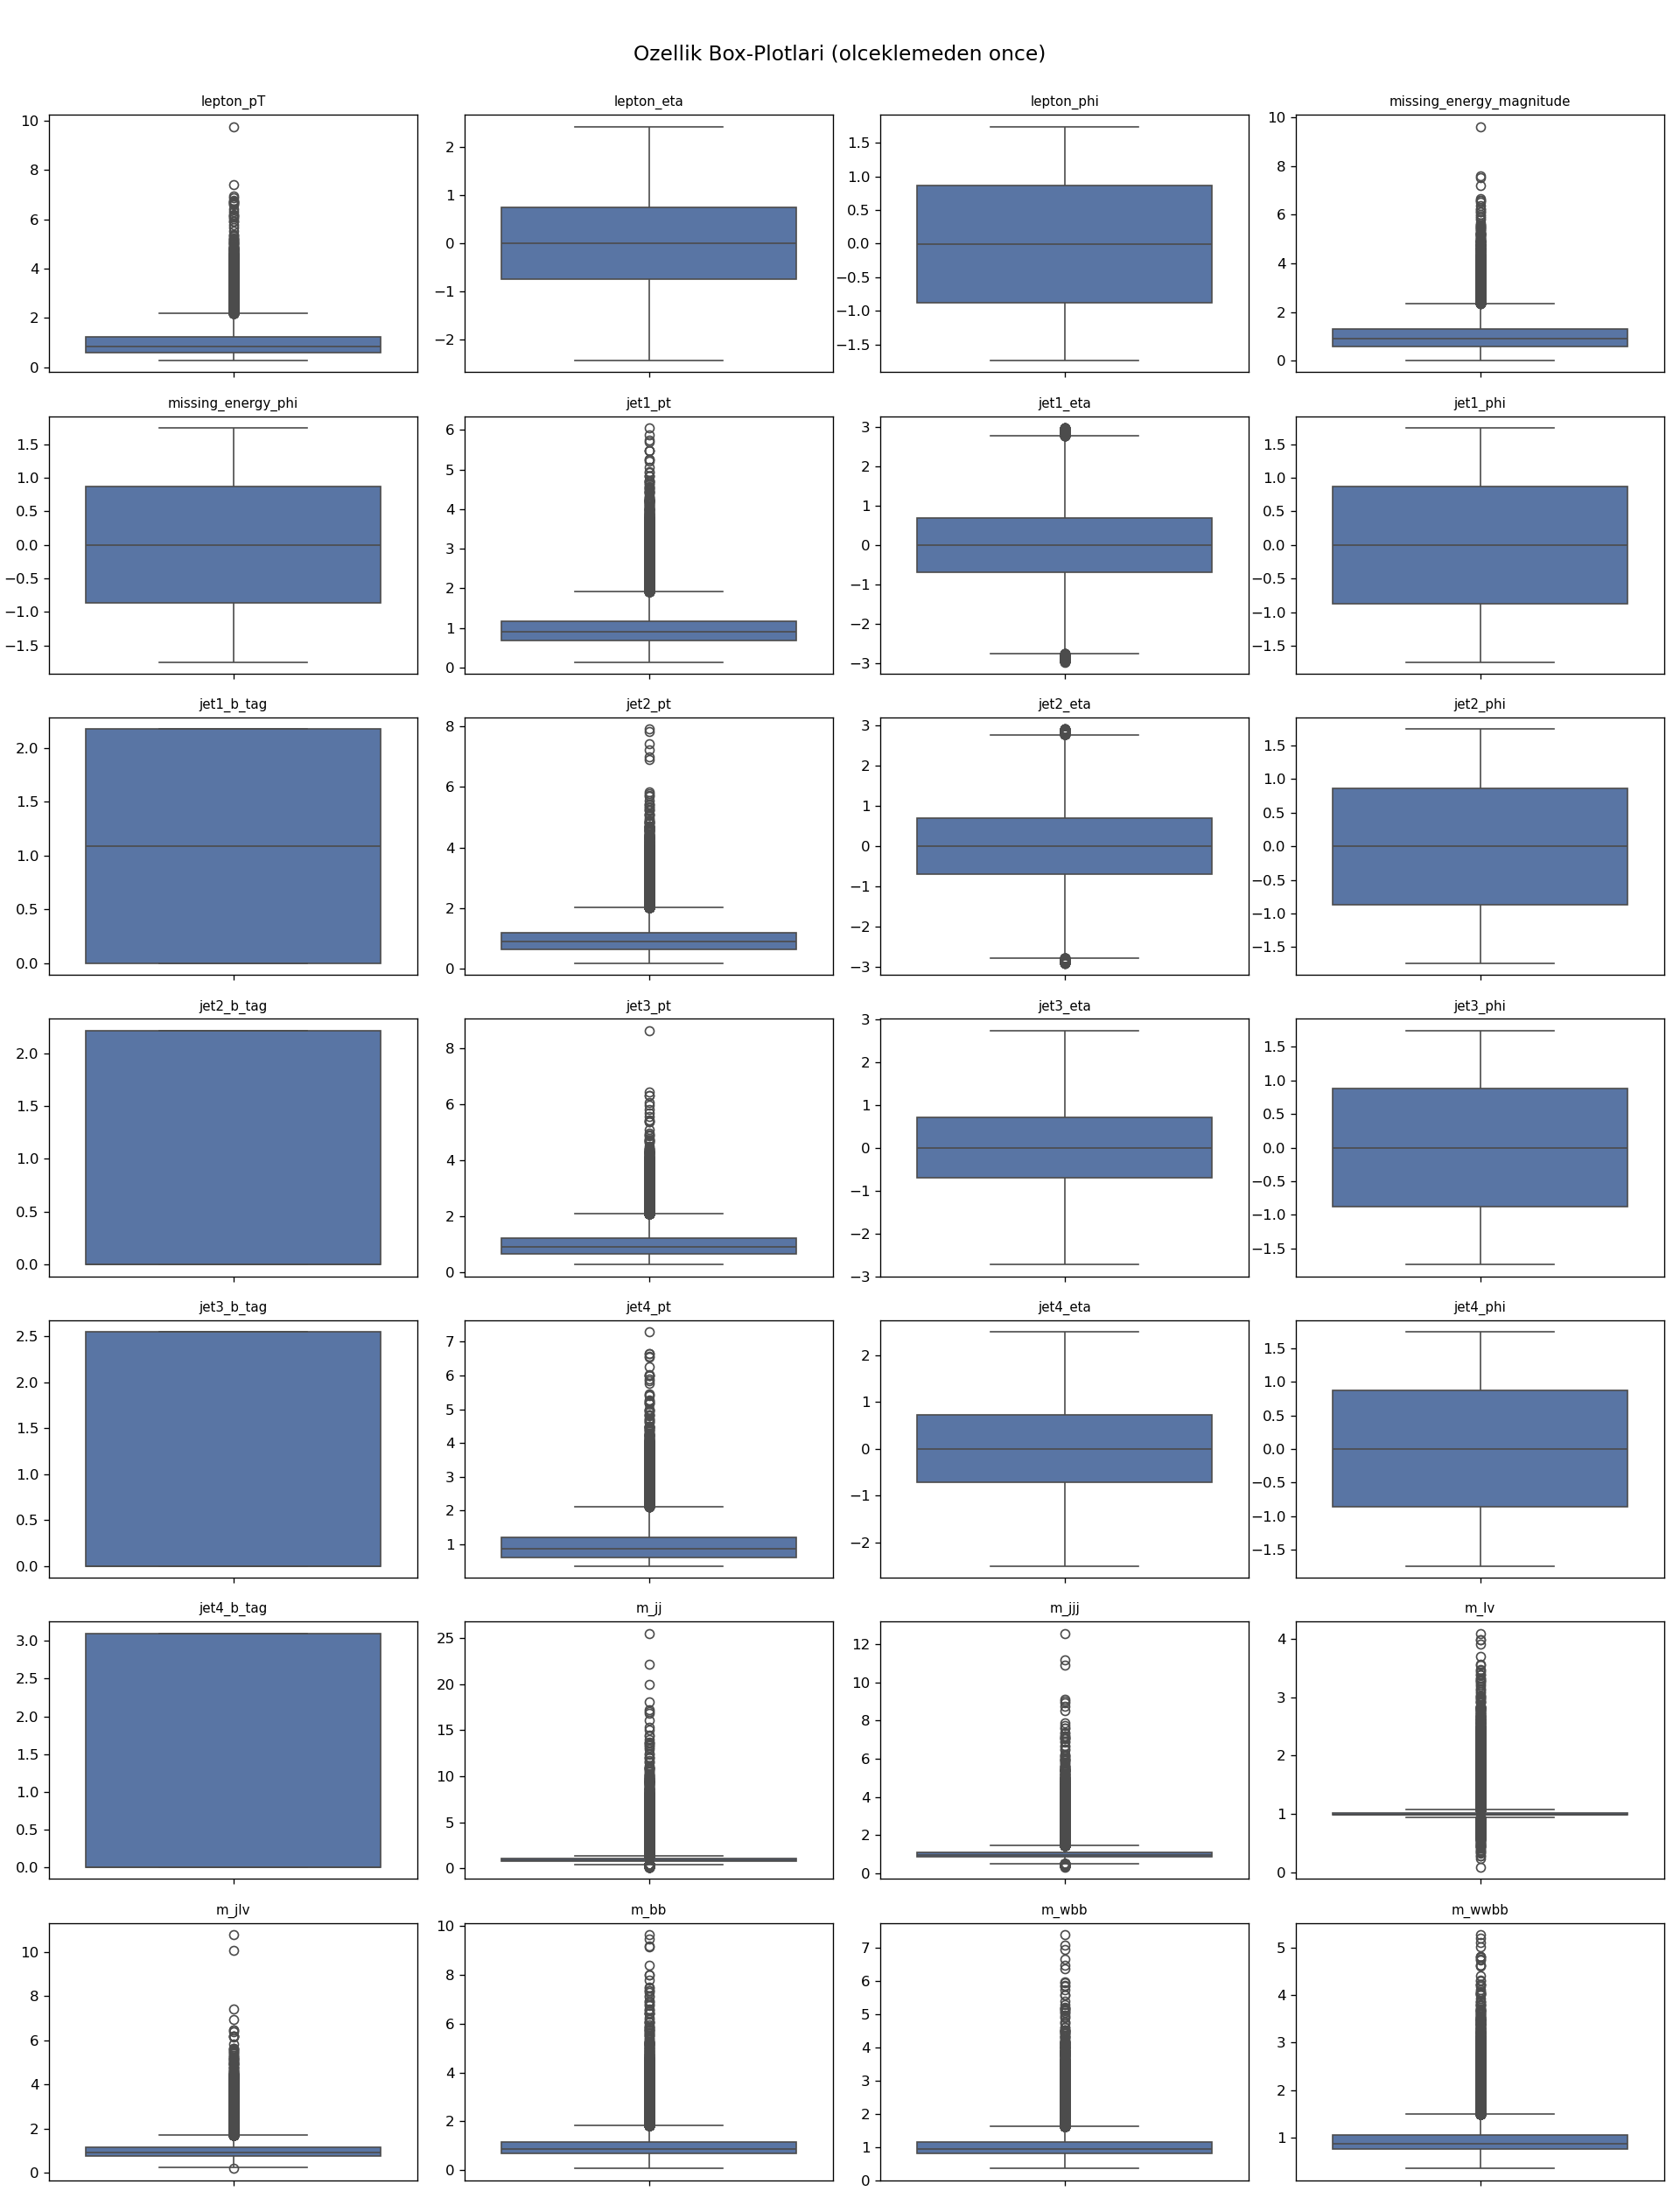

In [4]:
# Ölçeklemeden önce box-plot ile aykırı değerlerin görsel incelemesi
path = prep.plot_boxplots(X, fname='boxplots_before_scaling.png',
                          title='Ozellik Box-Plotlari (olceklemeden once)')
display(Image(path))

### 1.2 Aykırı Değerlerin Kırpılması(Winsorization)

Aykırı değerler silinmek yerine IQR sınırlarına kırpılır. Böylece 100.000 örneklik denge korunur ve uç değerlerin model egitimine olumsuz etkisi azaltılır.

[preprocessing] Box-plot kaydedildi: C:\Users\Mehmet\Desktop\Yüksek Lisans\Makine Öğrenmesi\Final\MehmetŞen_254312024_MakineÖğrenmesi_Final\outputs\figures\boxplots_after_clipping.png


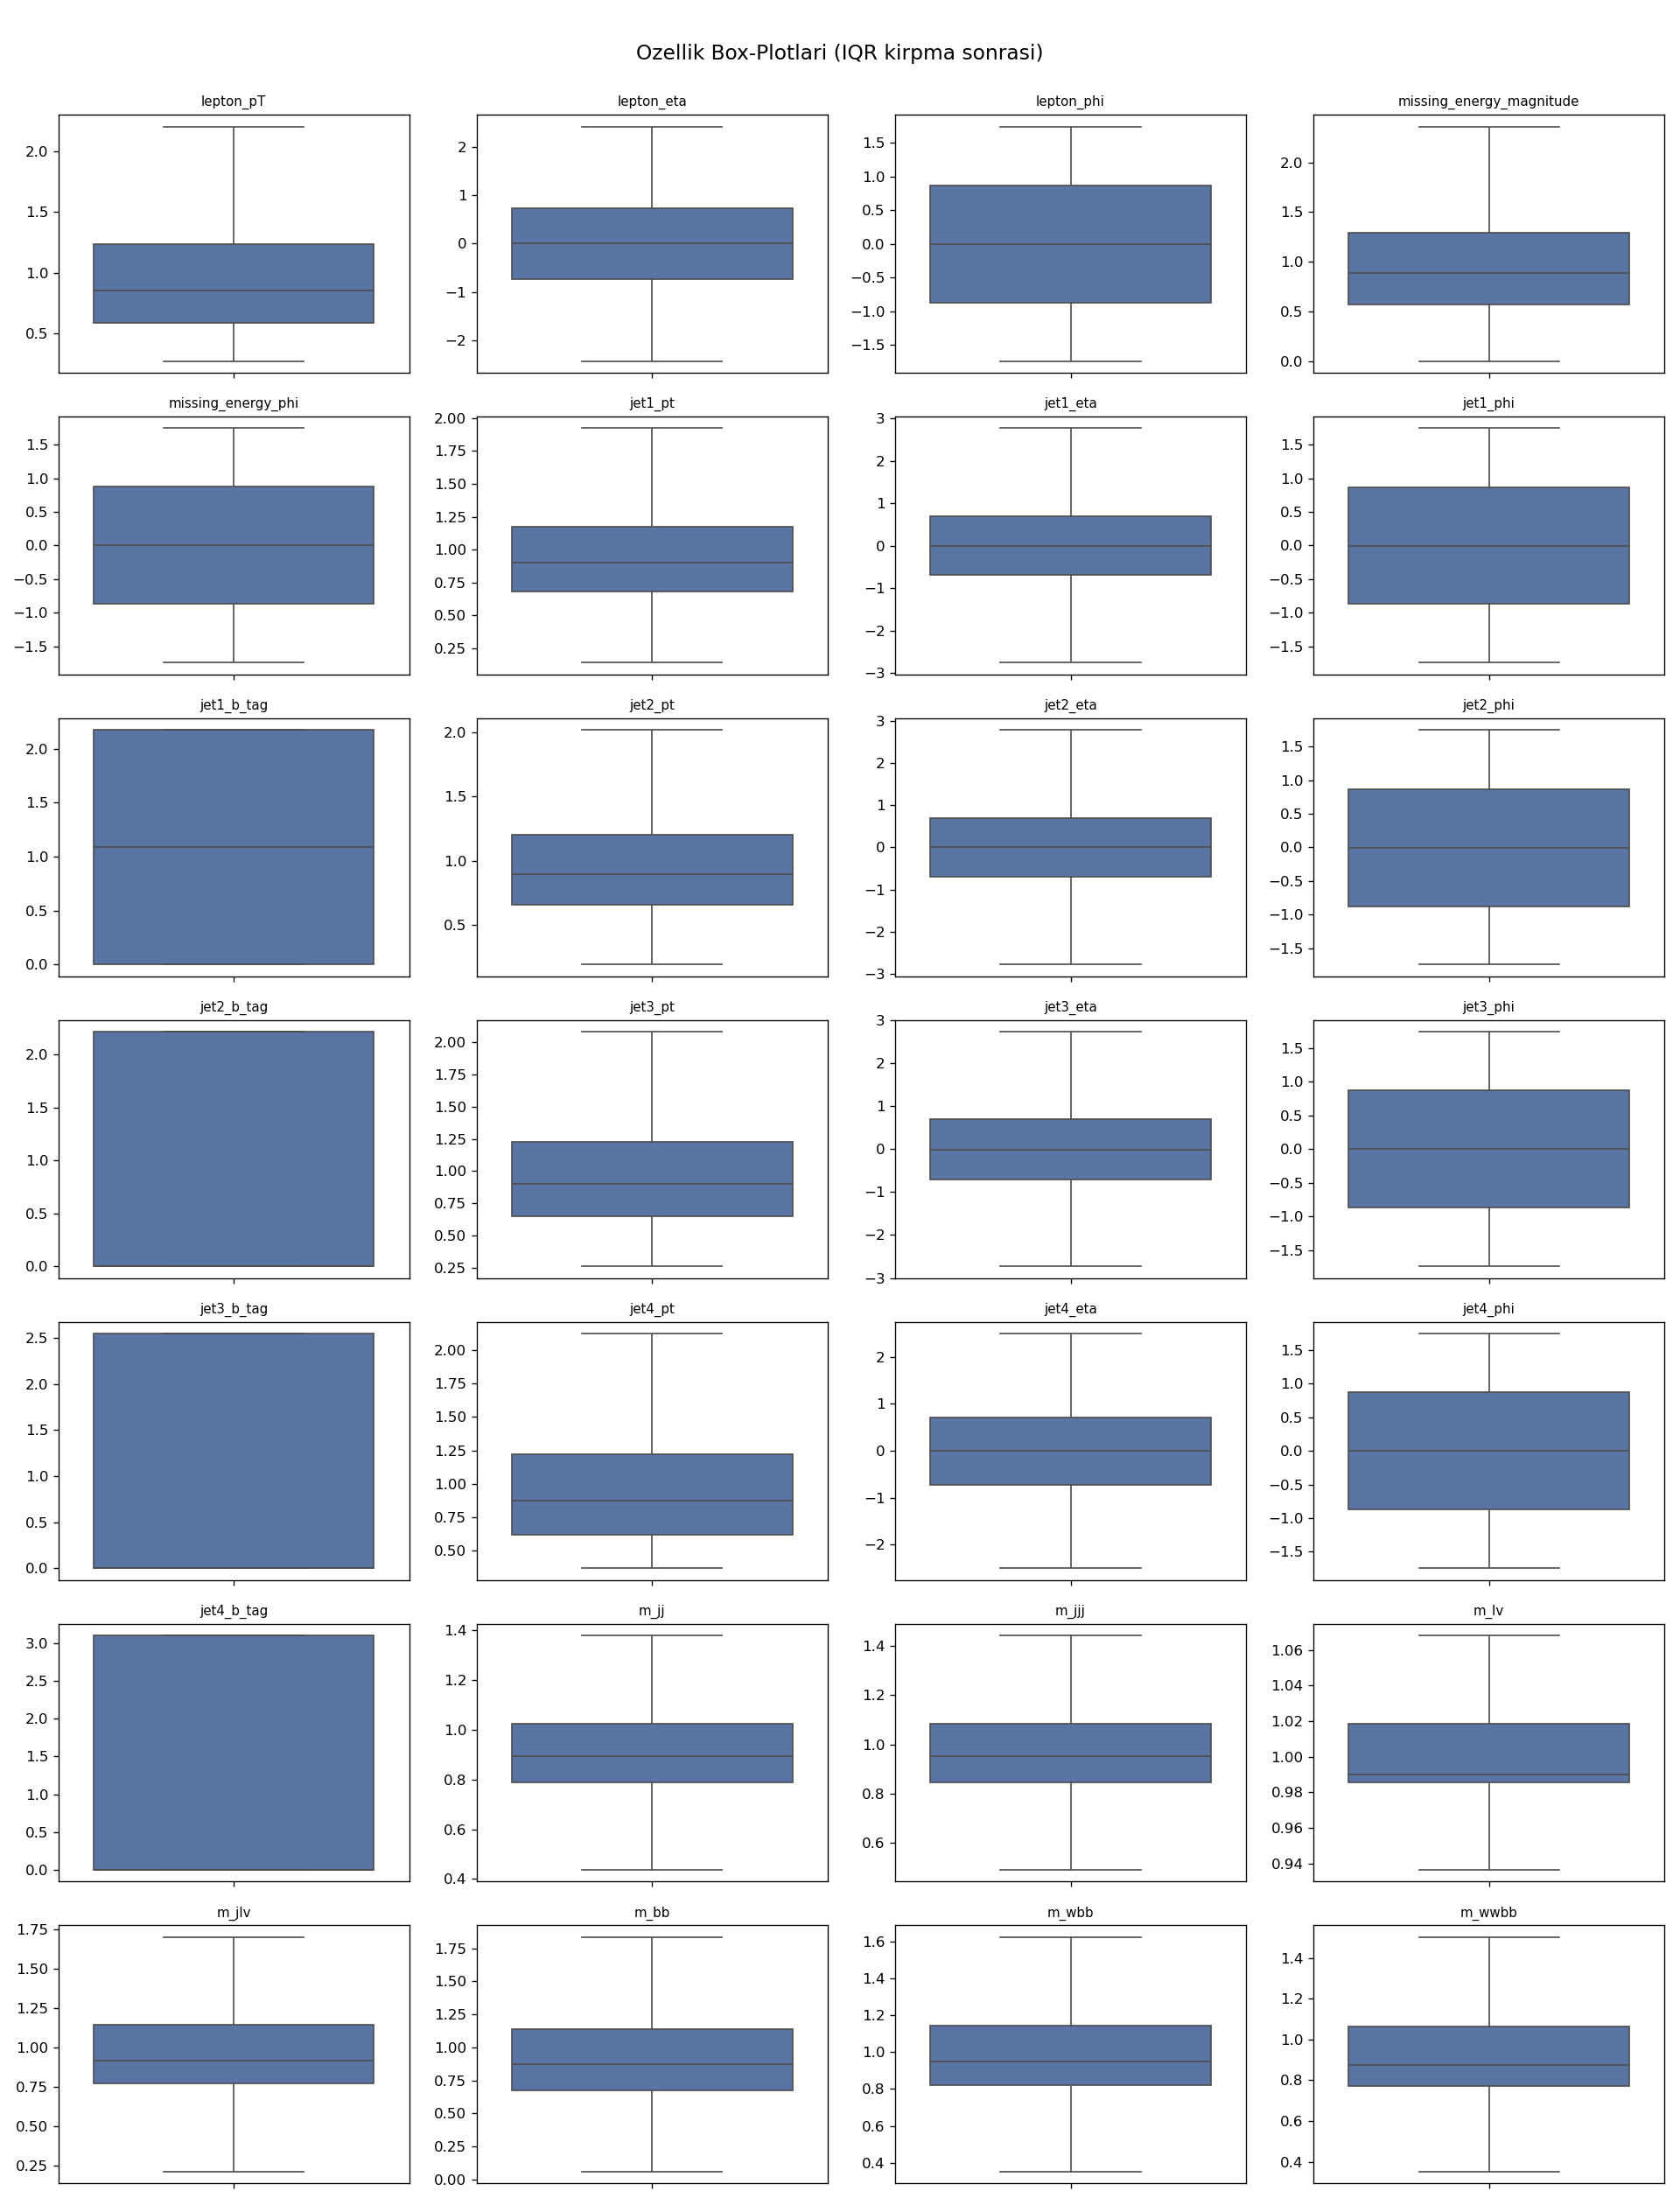

In [5]:
X_clipped = prep.clip_outliers_iqr(X)
path = prep.plot_boxplots(X_clipped, fname='boxplots_after_clipping.png',
                          title='Ozellik Box-Plotlari (IQR kirpma sonrasi)')
display(Image(path))

> **Not:** `MinMaxScaler` ile [0, 1] olcekleme, veri sizintisini onlemek icin her CV fold'unda yalnizca egitim verisine fit edilir. Bu nedenle olcekleme adimi modellerin `Pipeline`'i icine gomulmustur (bkz. `src/models.py`).

## Bölüm 2 - Filter-Based Özellik Seçimi
ANOVA F-score ile en iyi 15 özellik seçilir(yöntem `config.FEATURE_SELECTION_METHOD` ile değistirilebilir).

In [6]:
from src import feature_selection as fs

selected_features, ranked = fs.select_top_k(X_clipped, y)
print('Secilen en iyi {} ozellik:'.format(config.N_FEATURES_TO_SELECT))
for i, f in enumerate(selected_features, 1):
    print('  {:2d}. {}'.format(i, f))
ranked

[feature_selection] Ozellik skorlari kaydedildi: C:\Users\Mehmet\Desktop\Yüksek Lisans\Makine Öğrenmesi\Final\MehmetŞen_254312024_MakineÖğrenmesi_Final\outputs\results\feature_scores_anova.csv
Secilen en iyi 15 ozellik:
   1. m_bb
   2. m_wwbb
   3. missing_energy_magnitude
   4. m_wbb
   5. jet1_pt
   6. jet2_b_tag
   7. jet4_pt
   8. lepton_pT
   9. m_jjj
  10. jet2_pt
  11. jet3_b_tag
  12. m_jj
  13. jet4_b_tag
  14. jet3_pt
  15. jet1_b_tag


,feature,score
0,m_bb,2017.584279
1,m_wwbb,1898.062864
2,missing_energy_magnitude,836.045191
3,m_wbb,449.045019
4,jet1_pt,325.572263
5,jet2_b_tag,236.172326
6,jet4_pt,154.817609
7,lepton_pT,100.619212
8,m_jjj,86.367011
9,jet2_pt,48.155275


[feature_selection] Ozellik skor grafigi kaydedildi: C:\Users\Mehmet\Desktop\Yüksek Lisans\Makine Öğrenmesi\Final\MehmetŞen_254312024_MakineÖğrenmesi_Final\outputs\figures\feature_importance_scores.png


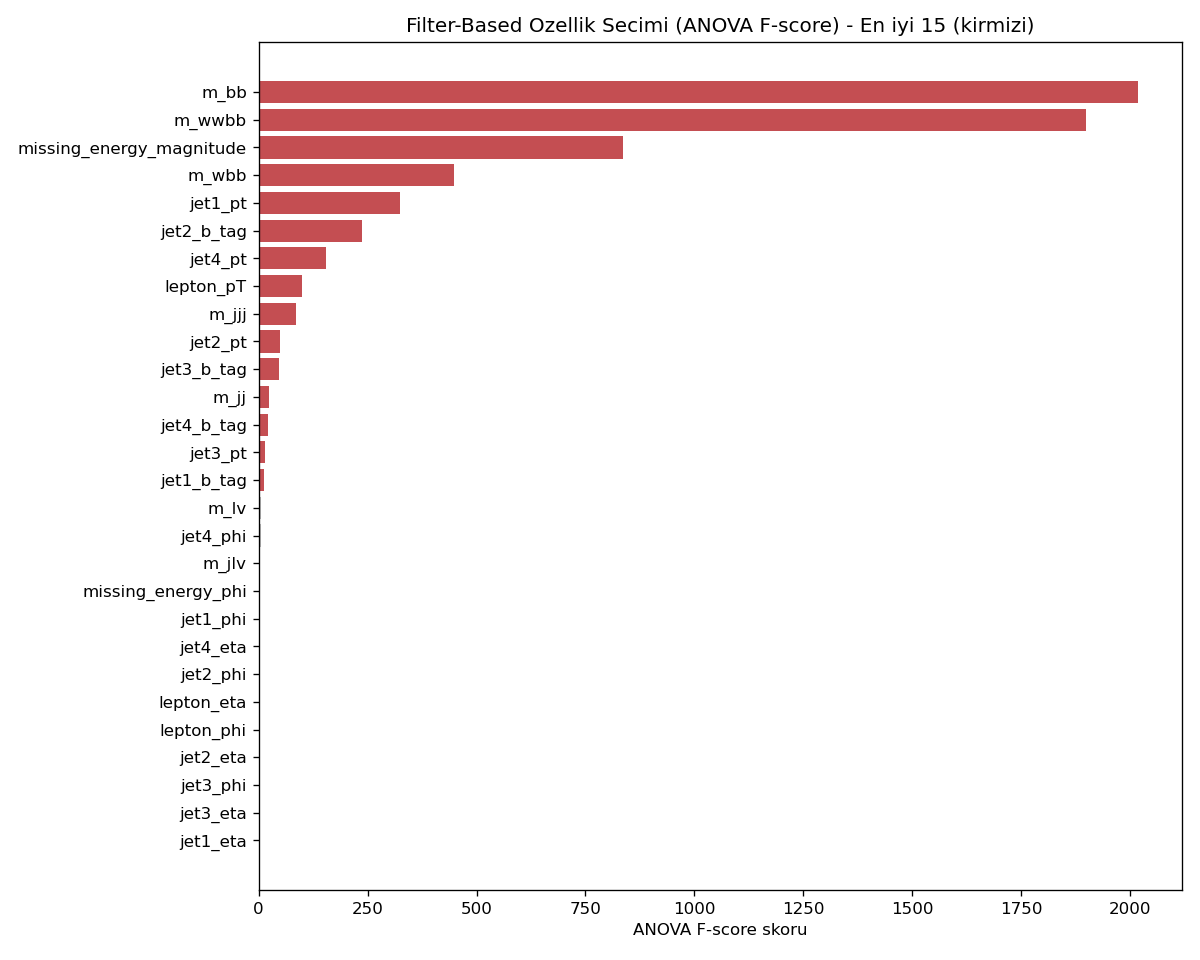

In [7]:
path = fs.plot_feature_scores(ranked)
display(Image(path))

## Bölüm 3 - Nested Cross-Validation

Outer Loop = 5-fold, Inner Loop = 3-fold.

SVM (rbf) ve MLP'nin 100.000 örnekte nested CV'si çok pahalı olduğundan, modelleme adımı dengeli bir alt-örnek üzerinde calışır. (`config.MODEL_SAMPLE_SIZE`).

In [8]:
from main import get_modeling_subset, run_flowchart, save_results

X_model, y_model = get_modeling_subset(X_clipped, y)
print('Modelleme alt-ornegi:', X_model.shape)

[main] Nested CV icin 6000 orneklik stratified alt-ornek kullaniliyor.
Modelleme alt-ornegi: (6000, 28)


### Flowchart B - İç döngüde HIPERPARAMETRE kombinasyonları
Her model için inner CV'de en iyi hiperparametreler seçilir, dış döngüde test performansı ölçülür.

In [9]:
results_B = run_flowchart(X_model, y_model, 'B')
summary_B = save_results(results_B, 'B')
summary_B.round(4)


=== BOLUM 3: NESTED CV - FLOWCHART B ===

>>> Model: KNN | Flowchart B | grid={'model__n_neighbors': [3, 5, 7, 9, 11]}
  [KNN] Fold 1/5 -> AUC=0.6149, F1=0.6351, params={'model__n_neighbors': 11}
  [KNN] Fold 2/5 -> AUC=0.6316, F1=0.6540, params={'model__n_neighbors': 9}
  [KNN] Fold 3/5 -> AUC=0.6475, F1=0.6518, params={'model__n_neighbors': 9}
  [KNN] Fold 4/5 -> AUC=0.6459, F1=0.6422, params={'model__n_neighbors': 11}
  [KNN] Fold 5/5 -> AUC=0.6518, F1=0.6628, params={'model__n_neighbors': 11}
    Tamamlandi (6.6s) | Ortalama AUC=0.6384

>>> Model: SVM | Flowchart B | grid={'model__C': [0.1, 1, 10], 'model__kernel': ['linear', 'rbf']}
  [SVM] Fold 1/5 -> AUC=0.7220, F1=0.6995, params={'model__C': 1, 'model__kernel': 'rbf'}
  [SVM] Fold 2/5 -> AUC=0.7226, F1=0.7128, params={'model__C': 1, 'model__kernel': 'rbf'}
  [SVM] Fold 3/5 -> AUC=0.7417, F1=0.7198, params={'model__C': 1, 'model__kernel': 'rbf'}
  [SVM] Fold 4/5 -> AUC=0.7292, F1=0.6988, params={'model__C': 1, 'model__kernel': 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  [MLP] Fold 1/5 -> AUC=0.7270, F1=0.6969, params={'model__activation': 'relu', 'model__hidden_layer_sizes': (100,)}


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  [MLP] Fold 2/5 -> AUC=0.7404, F1=0.6941, params={'model__activation': 'relu', 'model__hidden_layer_sizes': (50,)}


...

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  [MLP] Fold 4/5 -> AUC=0.7458, F1=0.7162, params={'model__activation': 'relu', 'model__hidden_layer_sizes': (50,)}


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  [MLP] Fold 5/5 -> AUC=0.7456, F1=0.6955, params={'model__activation': 'relu', 'model__hidden_layer_sizes': (100,)}
    Tamamlandi (23.9s) | Ortalama AUC=0.7416

>>> Model: XGBoost | Flowchart B | grid={'model__n_estimators': [100, 200], 'model__max_depth': [3, 6], 'model__learning_rate': [0.1, 0.3]}
  [XGBoost] Fold 1/5 -> AUC=0.7497, F1=0.6979, params={'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
  [XGBoost] Fold 2/5 -> AUC=0.7698, F1=0.7231, params={'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
  [XGBoost] Fold 3/5 -> AUC=0.7819, F1=0.7300, params={'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
  [XGBoost] Fold 4/5 -> AUC=0.7686, F1=0.7168, params={'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
  [XGBoost] Fold 5/5 -> AUC=0.7587, F1=0.7088, params={'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
    Tamamlandi (5.1s) 

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,KNN,0.6008,0.0147,0.6080,0.0136,0.6966,0.0161,0.6492,0.0107,0.6384,0.0152
1,SVM,0.6685,0.0075,0.6656,0.0090,0.7539,0.0239,0.7067,0.0092,0.7284,0.0080
2,MLP,0.6795,0.0044,0.6901,0.0167,0.7208,0.0429,0.7042,0.0120,0.7416,0.0088
3,XGBoost,0.6958,0.0135,0.7101,0.0144,0.7208,0.0173,0.7153,0.0125,0.7658,0.0122


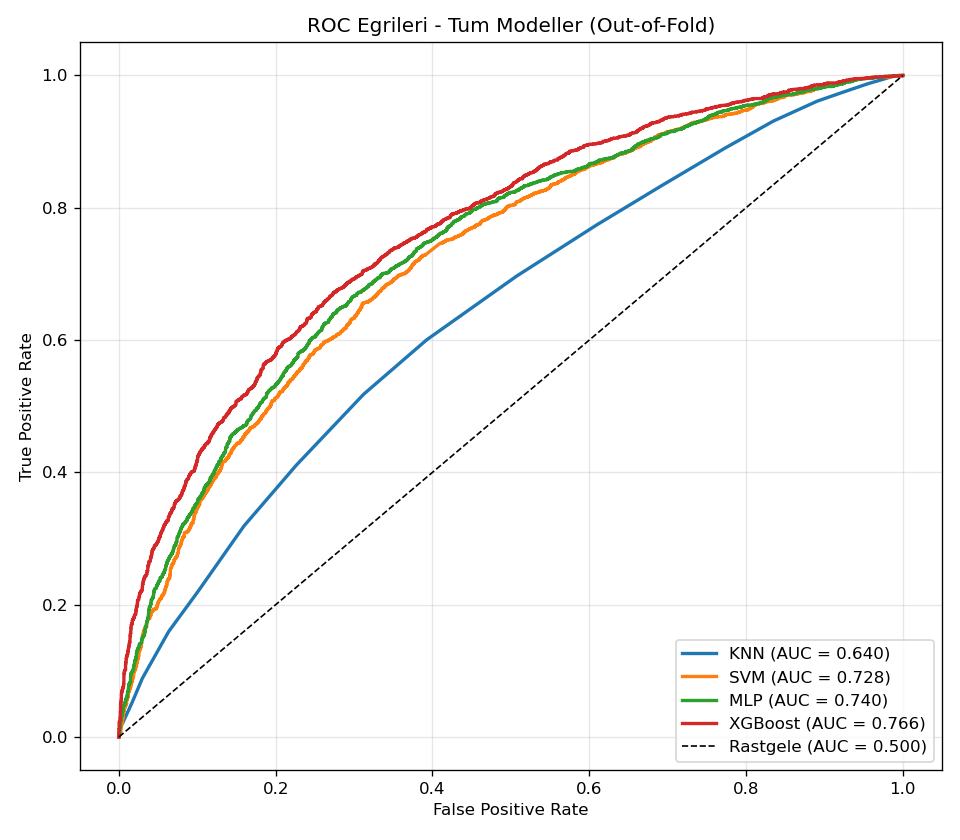

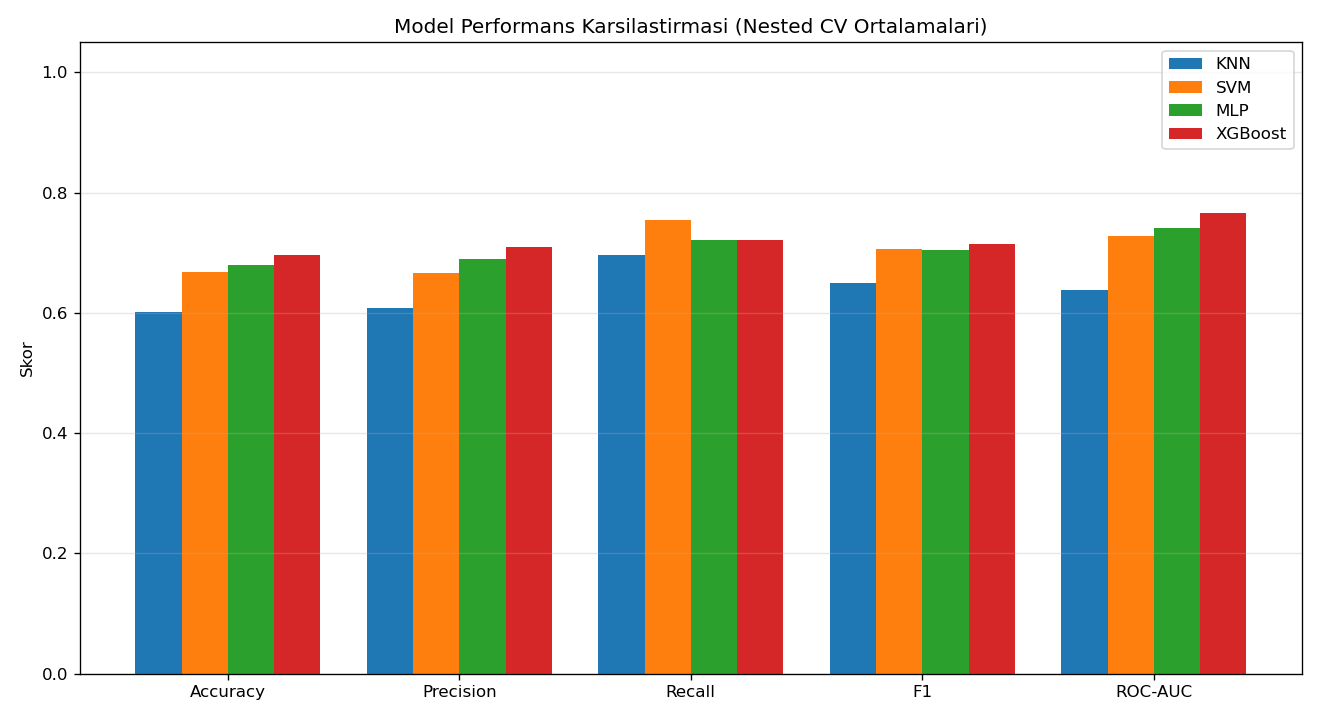

In [10]:
# ROC eğrileri ve metrik karşılaştırması(Flowchart B)
display(Image(os.path.join(config.FIGURES_DIR, 'roc_curves_all_models_flow_B.png')))
display(Image(os.path.join(config.FIGURES_DIR, 'metric_comparison_flow_B.png')))

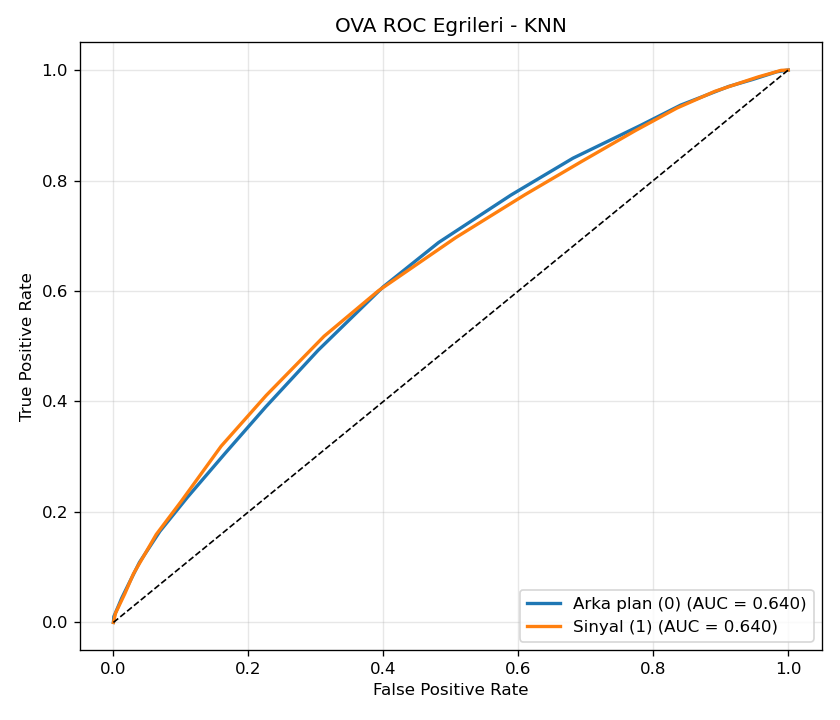

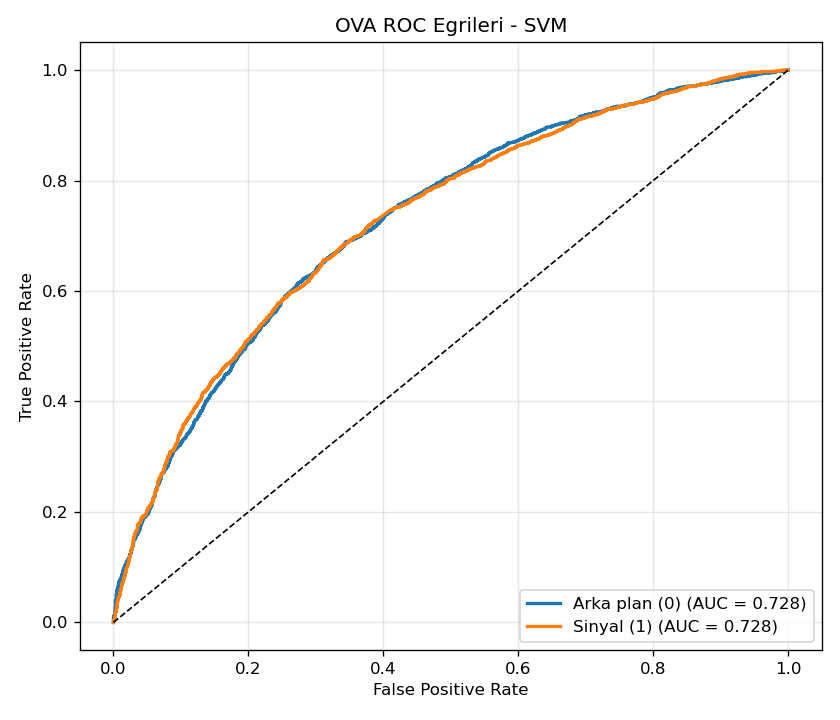

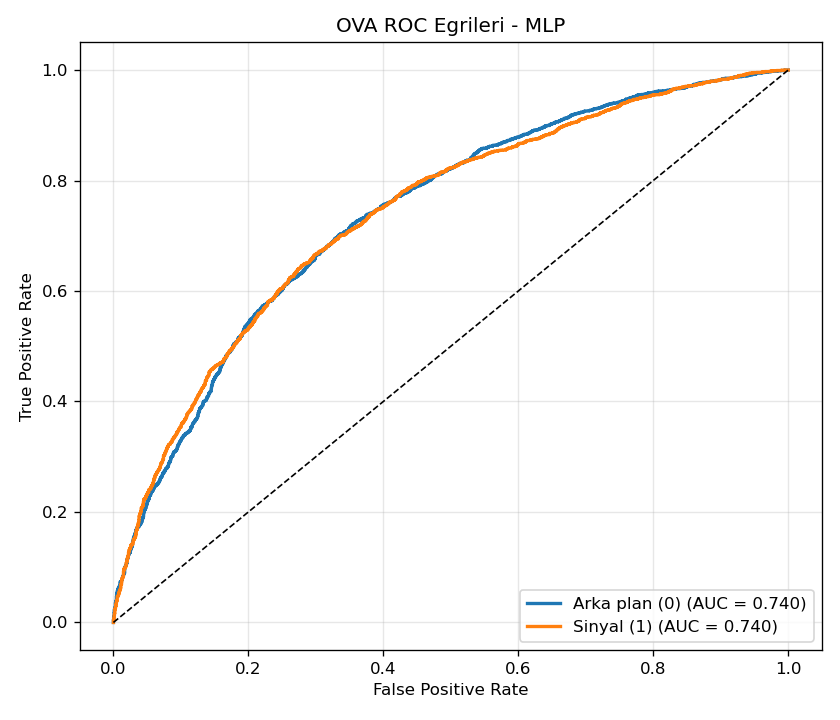

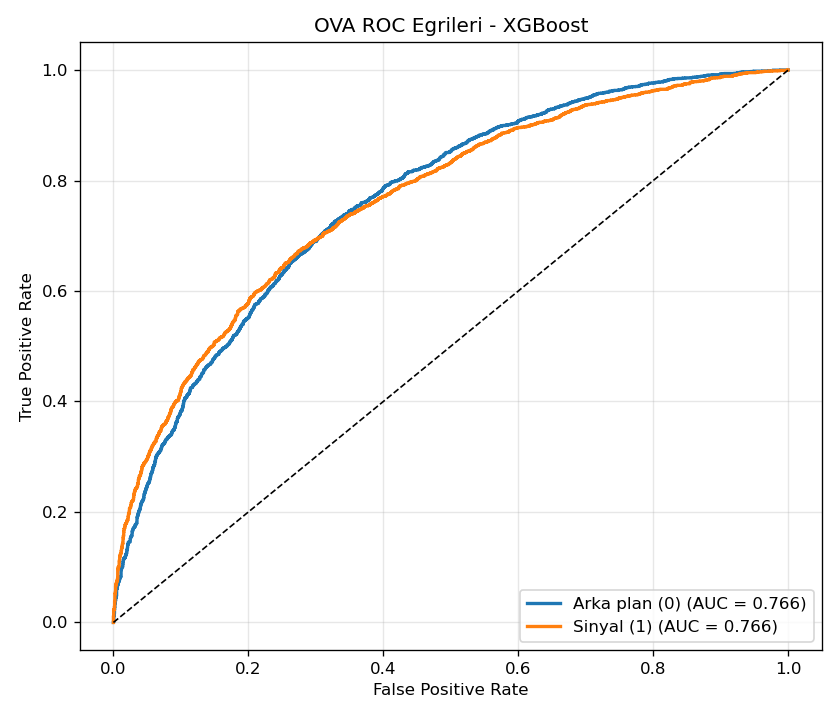

In [11]:
# Her model için OVA(One-vs-All) ROC eğrileri
from src.models import MODEL_NAMES
for name in MODEL_NAMES:
    display(Image(os.path.join(config.FIGURES_DIR, 'roc_ova_{}_flow_B.png'.format(name))))

In [12]:
# Her modelin dış fold'larda seçtiği en iyi hiperparametreler
for r in results_B:
    print('==', r['model'], '==')
    display(pd.DataFrame(r['best_params']))

== KNN ==


,model__n_neighbors
0,11
1,9
2,9
3,11
4,11


== SVM ==


,model__C,model__kernel
0,1,rbf
1,1,rbf
2,1,rbf
3,1,rbf
4,1,rbf


== MLP ==


,model__activation,model__hidden_layer_sizes
0,relu,"(100,)"
1,relu,"(50,)"
2,relu,"(50,)"
3,relu,"(50,)"
4,relu,"(100,)"


== XGBoost ==


,model__learning_rate,model__max_depth,model__n_estimators
0,0.1,3,100
1,0.1,3,100
2,0.1,3,100
3,0.1,3,100
4,0.1,3,100


### Flowchart A - İç döngüde ÖZNİTELİK SEÇİM kombinasyonları
Inner CV'de farkli özellik sayıları (`select__k`) denenerek en iyi öznitelik kombinasyonu seçilir.

In [13]:
results_A = run_flowchart(X_model, y_model, 'A')
summary_A = save_results(results_A, 'A')
summary_A.round(4)


=== BOLUM 3: NESTED CV - FLOWCHART A ===

>>> Model: KNN | Flowchart A | grid={'select__k': [10, 15, 20, 28]}
  [KNN] Fold 1/5 -> AUC=0.6560, F1=0.6657, params={'select__k': 10}
  [KNN] Fold 2/5 -> AUC=0.6335, F1=0.6532, params={'select__k': 10}
  [KNN] Fold 3/5 -> AUC=0.6462, F1=0.6558, params={'select__k': 10}
  [KNN] Fold 4/5 -> AUC=0.6591, F1=0.6566, params={'select__k': 10}
  [KNN] Fold 5/5 -> AUC=0.6323, F1=0.6349, params={'select__k': 10}
    Tamamlandi (1.6s) | Ortalama AUC=0.6454

>>> Model: SVM | Flowchart A | grid={'select__k': [10, 15, 20, 28]}
  [SVM] Fold 1/5 -> AUC=0.7260, F1=0.7126, params={'select__k': 10}
  [SVM] Fold 2/5 -> AUC=0.7154, F1=0.6905, params={'select__k': 10}
  [SVM] Fold 3/5 -> AUC=0.7415, F1=0.7168, params={'select__k': 10}
  [SVM] Fold 4/5 -> AUC=0.7430, F1=0.7166, params={'select__k': 10}
  [SVM] Fold 5/5 -> AUC=0.7317, F1=0.7042, params={'select__k': 10}
    Tamamlandi (32.9s) | Ortalama AUC=0.7315

>>> Model: MLP | Flowchart A | grid={'select__k': 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  [MLP] Fold 1/5 -> AUC=0.7333, F1=0.7071, params={'select__k': 10}
  [MLP] Fold 2/5 -> AUC=0.7374, F1=0.7011, params={'select__k': 10}


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  [MLP] Fold 3/5 -> AUC=0.7591, F1=0.7167, params={'select__k': 10}
  [MLP] Fold 4/5 -> AUC=0.7600, F1=0.7139, params={'select__k': 10}


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  [MLP] Fold 5/5 -> AUC=0.7431, F1=0.7044, params={'select__k': 10}
    Tamamlandi (25.2s) | Ortalama AUC=0.7466

>>> Model: XGBoost | Flowchart A | grid={'select__k': [10, 15, 20, 28]}
  [XGBoost] Fold 1/5 -> AUC=0.7460, F1=0.6918, params={'select__k': 28}
  [XGBoost] Fold 2/5 -> AUC=0.7639, F1=0.7278, params={'select__k': 28}
  [XGBoost] Fold 3/5 -> AUC=0.7606, F1=0.7055, params={'select__k': 28}
  [XGBoost] Fold 4/5 -> AUC=0.7592, F1=0.7029, params={'select__k': 28}
  [XGBoost] Fold 5/5 -> AUC=0.7495, F1=0.7005, params={'select__k': 28}
    Tamamlandi (3.7s) | Ortalama AUC=0.7558

[main] Ozet metrikler kaydedildi: C:\Users\Mehmet\Desktop\Yüksek Lisans\Makine Öğrenmesi\Final\MehmetŞen_254312024_MakineÖğrenmesi_Final\outputs\results\metrics_summary_flow_A.csv
  model  accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean  f1_std  roc_auc_mean  roc_auc_std
    KNN         0.6102        0.0140          0.6183         0.0140       0.6925      0.0166

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,KNN,0.6102,0.0140,0.6183,0.0140,0.6925,0.0166,0.6532,0.0113,0.6454,0.0124
1,SVM,0.6682,0.0149,0.6638,0.0162,0.7592,0.0158,0.7081,0.0111,0.7315,0.0114
2,MLP,0.6833,0.0083,0.6921,0.0138,0.7265,0.0182,0.7087,0.0065,0.7466,0.0123
3,XGBoost,0.6858,0.0123,0.7008,0.0088,0.7108,0.0191,0.7057,0.0134,0.7558,0.0077


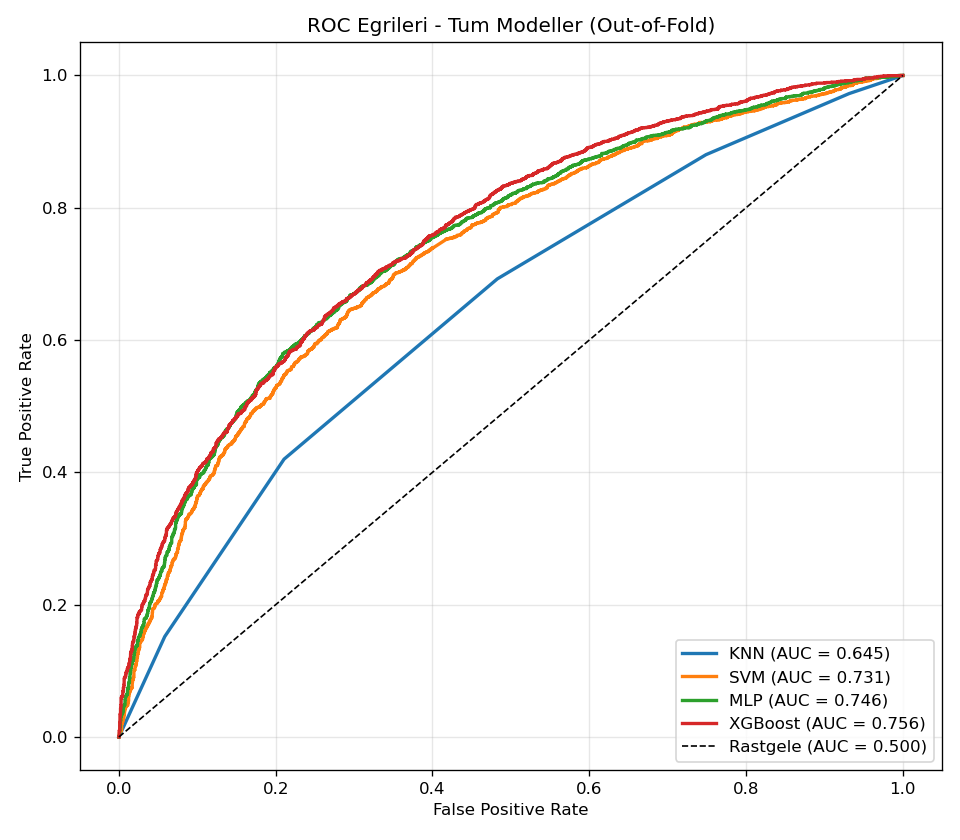

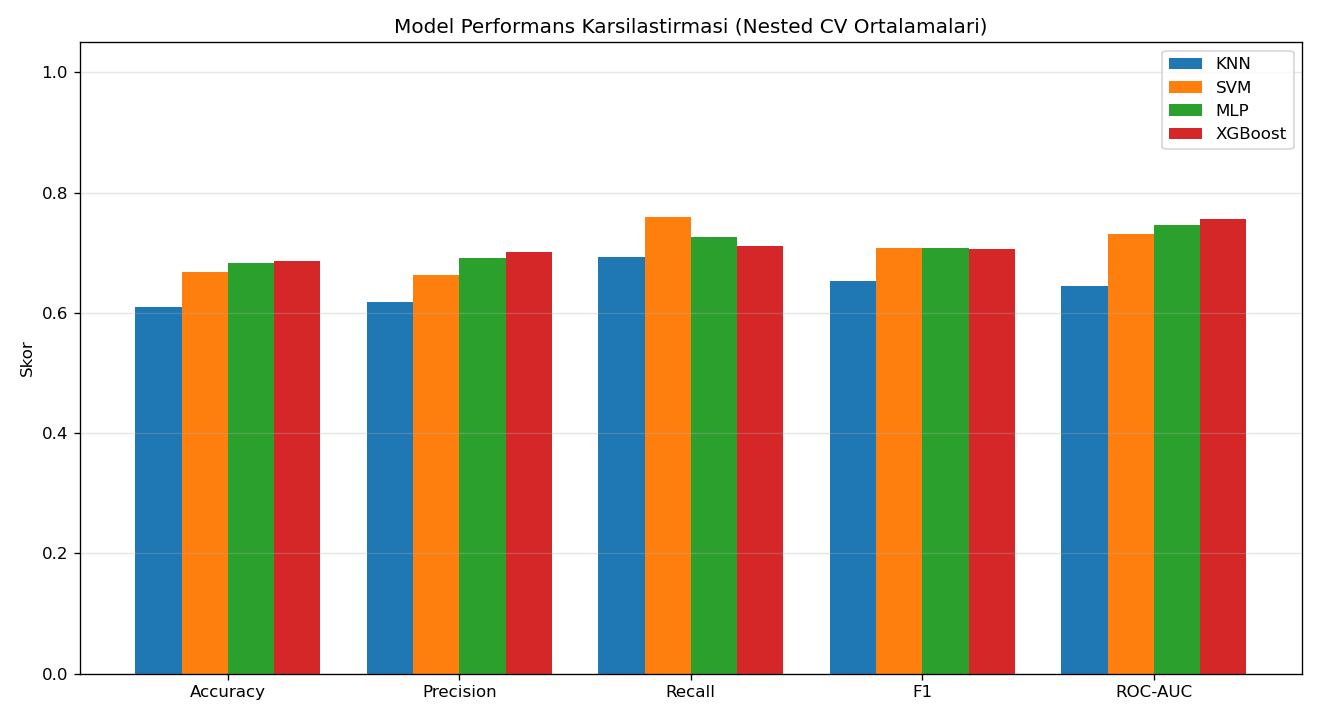

In [14]:
display(Image(os.path.join(config.FIGURES_DIR, 'roc_curves_all_models_flow_A.png')))
display(Image(os.path.join(config.FIGURES_DIR, 'metric_comparison_flow_A.png')))

## Sonuç 

- `summary_B` tablosu her modelin Accuracy / Precision / Recall / F1 / ROC-AUC ortalamalarını içerir.
- En yüksek ROC-AUC'ye sahip model en başarılı kabul edilir.

Aşagıdaki hücre, iki flowchart için de en iyi modeli özetler:

In [15]:
for flow, summ in [('A', summary_A), ('B', summary_B)]:
    best = summ.loc[summ['roc_auc_mean'].idxmax()]
    print('Flowchart {} -> En iyi model: {} (ROC-AUC = {:.4f}, F1 = {:.4f})'.format(
        flow, best['model'], best['roc_auc_mean'], best['f1_mean']))

Flowchart A -> En iyi model: XGBoost (ROC-AUC = 0.7558, F1 = 0.7057)
Flowchart B -> En iyi model: XGBoost (ROC-AUC = 0.7658, F1 = 0.7153)
